# OGM Feature Model Analysis

## 1. Imports & Exploratory Analysis

Imports and shared run-size constants always execute. The exploratory checks below (retrieval-length sanity check, network visualizations) are commented out by default to keep full-notebook runs fast - uncomment individual cells if you want to inspect them.

In [1]:
import model_features as model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Fast-iteration run size (temporary) ------------------------------------
# Every experiment cell below reads these instead of hardcoding retrieval/rep
# counts, so the whole notebook runs quickly while we confirm the new
# analyses (FeatureAgent decay sweep, growing-trauma network) work correctly.
#
# ORIGINAL / TARGET VALUES (used for the earlier published-style figures):
#   N_RETRIEVALS = 100, N_REPS = 20, SWEEP_REPS = 10
# Restore these once everything below is confirmed working, then re-run the
# notebook top to bottom for the final figures.
# N_RETRIEVALS = 25
# MAX_STEPS = 50
# N_REPS = 1
# SWEEP_REPS = 1
N_RETRIEVALS = 100
MAX_STEPS = 50
N_REPS = 20
SWEEP_REPS = 10

In [3]:
# Exploratory sanity check - uncomment to run.
# default_rewards = {i: 1 for i in range(100)}
# default_rewards[0] = -10
# env = model.Memory(100, default_rewards, trauma=(0, 1), num_groups=5, group_features=3, max_assoc_strength=5.0)
# agent = model.FeatureAgent(env)
# sim = model.Simulator(agent, env)
# sim.run(25, 100, time=0.1, delta=20)
# for retrieval in sim.record:
#     print(len(retrieval))

In [4]:
# Exploratory network visualization (FeatureAgent) - uncomment to run.
# default_rewards = {i: 1 for i in range(100)}
# default_rewards[0] = -50
# env = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
# agent = model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05)
# sim = model.Simulator(agent, env)
# sim.run(N_RETRIEVALS, MAX_STEPS, time=0.1, delta=20, visualize=True)

In [5]:
# Exploratory network visualization (Agent) - uncomment to run.
# default_rewards = {i: 1 for i in range(100)}
# default_rewards[0] = -50
# env = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
# agent = model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05)
# sim = model.Simulator(agent, env)
# sim.run(N_RETRIEVALS, MAX_STEPS, time=0.1, delta=20, visualize=True, output_dir="retrieval_frames_agent")

## 2. Agent vs FeatureAgent Comparison

Direct comparison of the single-value `Agent` against the per-feature-value `FeatureAgent`, in order: a single-run illustration with trauma-encounter markers (`single_run.png`), the original network with one fixed trauma node from initialization (`comparison_1.png`), and a network where a new trauma memory keeps being added over time (`comparison_2.png`). `collect_trajectories` / `mean_sem` / `sweep_param` defined here are reused throughout the rest of the notebook.

In [6]:
def collect_trajectories(agent_factory, n=N_RETRIEVALS, max_steps=MAX_STEPS, reps=N_REPS,
                          delta=20, trauma=False, trauma_freq=1):
    length_trajectories = []
    reward_trajectories = []
    for _ in range(reps):
        environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
        agent = agent_factory(environment)
        sim = model.Simulator(agent, environment)
        sim.run(n, max_steps, time=0.1, delta=delta, trauma=trauma, trauma_freq=trauma_freq)
        length_trajectories.append([len(trial) for trial in sim.record])
        reward_trajectories.append(sim.reward_totals)
        print(f"rep {_} finished")
    return np.array(length_trajectories), np.array(reward_trajectories)


def mean_sem(arr):
    """Mean and standard error of the mean across reps (axis 0). SEM is 0 when
    there's only 1 rep (e.g. during fast-iteration runs with N_REPS=1)."""
    mean = arr.mean(axis=0)
    reps = arr.shape[0]
    sem = arr.std(axis=0, ddof=1) / np.sqrt(reps) if reps > 1 else np.zeros_like(mean)
    return mean, sem


def sweep_param(agent_builder, param_values, n=N_RETRIEVALS, max_steps=MAX_STEPS, reps=SWEEP_REPS,
                 trauma=False, trauma_freq=1):
    """For each value in param_values, run `reps` independent simulations
    (agent constructed via agent_builder(env, value)) and summarize two ways:
    average retrieval length across the whole run, and total cumulative
    reward accrued by the end of the run.

    Generic over whichever single hyperparameter agent_builder varies
    (decay_rate, temp, ...) - reused for the decay-rate sweep, temperature
    sweep, and the growing-trauma decay-rate sweep.
    """
    avg_length_mean, avg_length_sem = [], []
    cum_reward_mean, cum_reward_sem = [], []
    for value in param_values:
        lengths, rewards = collect_trajectories(
            lambda env, value=value: agent_builder(env, value),
            n=n, max_steps=max_steps, reps=reps, trauma=trauma, trauma_freq=trauma_freq)
        rep_avg_length = lengths.mean(axis=1)
        rep_cum_reward = rewards.sum(axis=1)  # total reward accrued over the whole run, per rep
        avg_length_mean.append(rep_avg_length.mean())
        avg_length_sem.append(rep_avg_length.std(ddof=1) / np.sqrt(reps) if reps > 1 else 0.0)
        cum_reward_mean.append(rep_cum_reward.mean())
        cum_reward_sem.append(rep_cum_reward.std(ddof=1) / np.sqrt(reps) if reps > 1 else 0.0)
    return (np.array(avg_length_mean), np.array(avg_length_sem),
            np.array(cum_reward_mean), np.array(cum_reward_sem))


default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -50

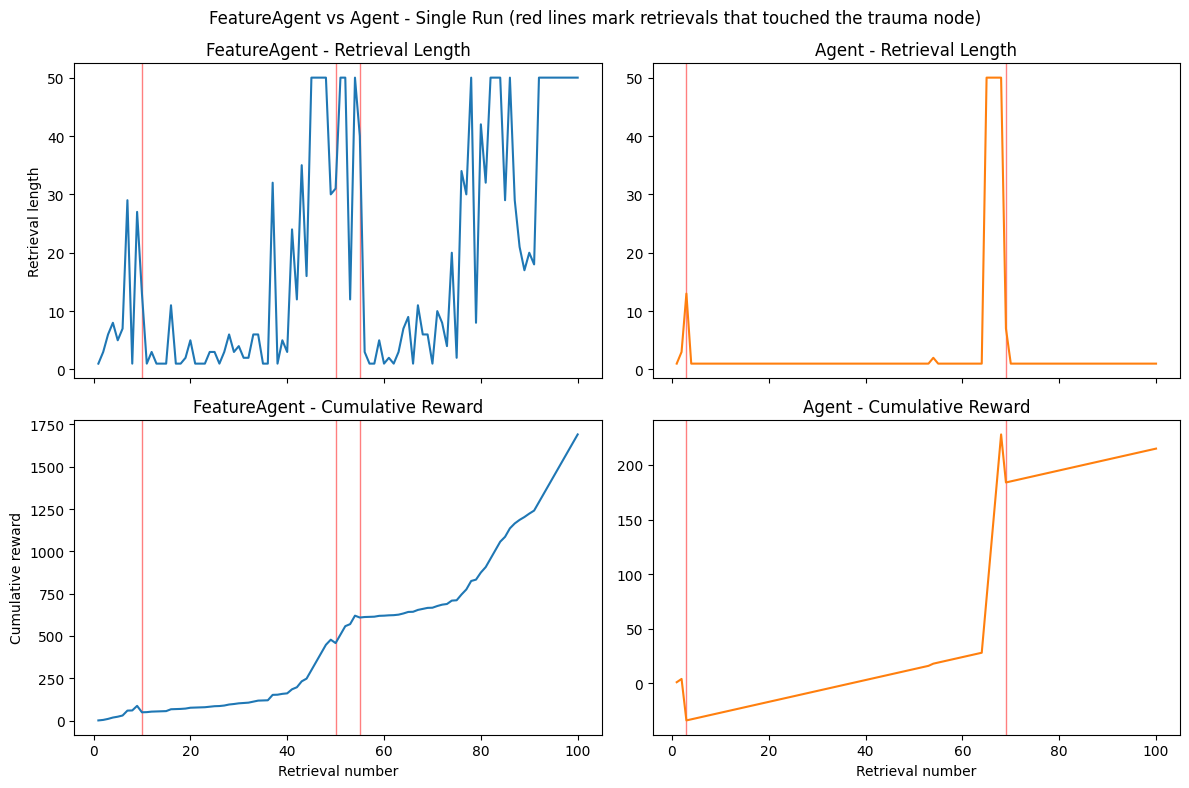

In [7]:
def single_run(agent_factory, n=N_RETRIEVALS, max_steps=MAX_STEPS):
    environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
    agent = agent_factory(environment)
    sim = model.Simulator(agent, environment)
    sim.run(n, max_steps, time=0.1, delta=20)
    lengths = [len(trial) for trial in sim.record]
    return np.array(lengths), np.array(sim.reward_totals), np.array(sim.trauma_encounters)

feature_lengths_1, feature_rewards_1, feature_trauma_1 = single_run(
    lambda env: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05))
agent_lengths_1, agent_rewards_1, agent_trauma_1 = single_run(
    lambda env: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05))

retrieval_num_1 = np.arange(1, len(feature_lengths_1) + 1)
feature_cumulative_reward_1 = np.cumsum(feature_rewards_1)
agent_cumulative_reward_1 = np.cumsum(agent_rewards_1)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axs[0][0].plot(retrieval_num_1, feature_lengths_1, color="C0")
axs[0][0].set_title("FeatureAgent - Retrieval Length")
axs[0][0].set_ylabel("Retrieval length")
axs[0][1].plot(retrieval_num_1, agent_lengths_1, color="C1")
axs[0][1].set_title("Agent - Retrieval Length")

axs[1][0].plot(retrieval_num_1, feature_cumulative_reward_1, color="C0")
axs[1][0].set_title("FeatureAgent - Cumulative Reward")
axs[1][0].set_ylabel("Cumulative reward")
axs[1][0].set_xlabel("Retrieval number")
axs[1][1].plot(retrieval_num_1, agent_cumulative_reward_1, color="C1")
axs[1][1].set_title("Agent - Cumulative Reward")
axs[1][1].set_xlabel("Retrieval number")

for ax, hits in [(axs[0][0], feature_trauma_1), (axs[1][0], feature_trauma_1),
                  (axs[0][1], agent_trauma_1), (axs[1][1], agent_trauma_1)]:
    for x in retrieval_num_1[hits]:
        ax.axvline(x, color="red", alpha=0.5, linewidth=1, zorder=0)

fig.suptitle("FeatureAgent vs Agent - Single Run (red lines mark retrievals that touched the trauma node)")
plt.tight_layout()
plt.savefig("plots/single_run.png")
plt.show()

rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 15 finished


rep 16 finished


rep 17 finished


rep 18 finished


rep 19 finished


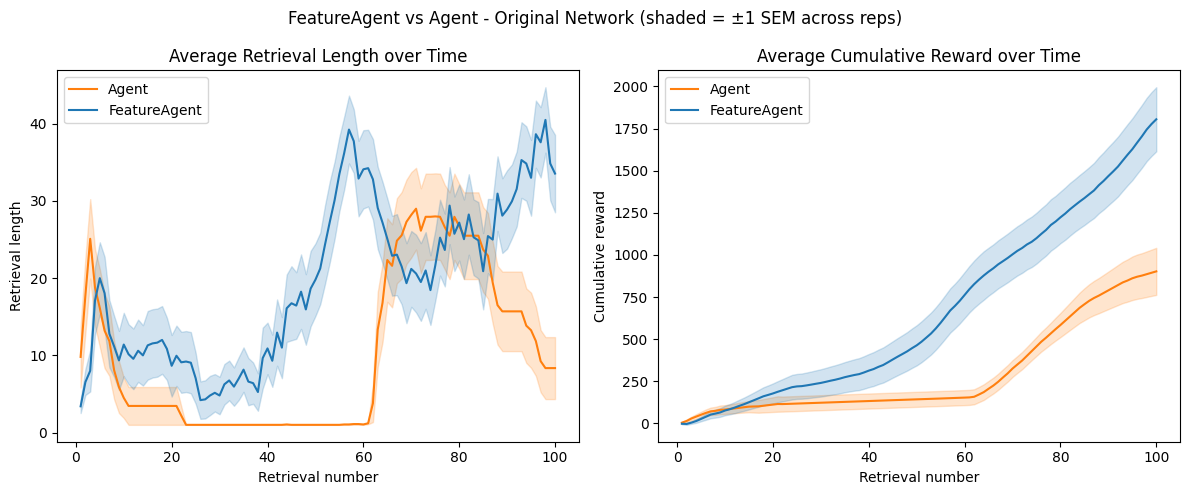

In [8]:
# v_i=0 equalizes Agent's starting value with FeatureAgent's (psi=w=0 -> value=0),
# so both start from the same neutral sigmoid(0/temp)=0.5 recall probability.
feature_lengths, feature_rewards = collect_trajectories(lambda env: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05))
agent_lengths, agent_rewards = collect_trajectories(lambda env: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05))

retrieval_num = np.arange(1, feature_lengths.shape[1] + 1)

# Cumulative reward per rep (running total across retrievals within each rep), then averaged over reps.
feature_cumulative_rewards = np.cumsum(feature_rewards, axis=1)
agent_cumulative_rewards = np.cumsum(agent_rewards, axis=1)

feature_length_mean, feature_length_sem = mean_sem(feature_lengths)
agent_length_mean, agent_length_sem = mean_sem(agent_lengths)
feature_cum_mean, feature_cum_sem = mean_sem(feature_cumulative_rewards)
agent_cum_mean, agent_cum_sem = mean_sem(agent_cumulative_rewards)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(retrieval_num, agent_length_mean, label="Agent", color="C1")
axs[0].fill_between(retrieval_num, agent_length_mean - agent_length_sem, agent_length_mean + agent_length_sem, color="C1", alpha=0.2)
axs[0].plot(retrieval_num, feature_length_mean, label="FeatureAgent", color="C0")
axs[0].fill_between(retrieval_num, feature_length_mean - feature_length_sem, feature_length_mean + feature_length_sem, color="C0", alpha=0.2)
axs[0].set_xlabel("Retrieval number")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length over Time")
axs[0].legend()

axs[1].plot(retrieval_num, agent_cum_mean, label="Agent", color="C1")
axs[1].fill_between(retrieval_num, agent_cum_mean - agent_cum_sem, agent_cum_mean + agent_cum_sem, color="C1", alpha=0.2)
axs[1].plot(retrieval_num, feature_cum_mean, label="FeatureAgent", color="C0")
axs[1].fill_between(retrieval_num, feature_cum_mean - feature_cum_sem, feature_cum_mean + feature_cum_sem, color="C0", alpha=0.2)
axs[1].set_xlabel("Retrieval number")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Average Cumulative Reward over Time")
axs[1].legend()

fig.suptitle("FeatureAgent vs Agent - Original Network (shaded = ±1 SEM across reps)")
plt.tight_layout()
plt.savefig("plots/comparison_1.png")
plt.show()

rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 15 finished


rep 16 finished


rep 17 finished


rep 18 finished


rep 19 finished


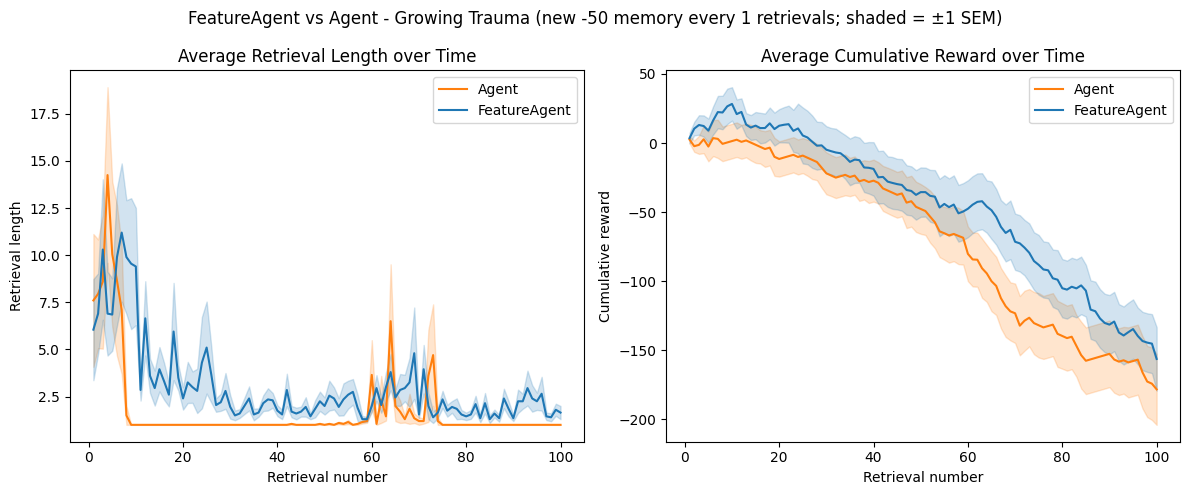

In [ ]:
# # Same FeatureAgent vs Agent comparison as above, but now the network keeps
# # accruing new trauma memories over time instead of having just the single
# # fixed trauma node from initialization: every TRAUMA_FREQ retrievals, one new
# # memory with reward=-50 is added (in addition to the regular delta batch of
# # neutral memories), via Simulator.run's trauma/trauma_freq parameters.
# TRAUMA_FREQ = 1
# feature_lengths_gt, feature_rewards_gt = collect_trajectories(
#     lambda env: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05),
#     trauma=-50, trauma_freq=TRAUMA_FREQ)
# agent_lengths_gt, agent_rewards_gt = collect_trajectories(
#     lambda env: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05),
#     trauma=-50, trauma_freq=TRAUMA_FREQ)

# retrieval_num_gt = np.arange(1, feature_lengths_gt.shape[1] + 1)

# feature_cumulative_rewards_gt = np.cumsum(feature_rewards_gt, axis=1)
# agent_cumulative_rewards_gt = np.cumsum(agent_rewards_gt, axis=1)

# feature_length_mean_gt, feature_length_sem_gt = mean_sem(feature_lengths_gt)
# agent_length_mean_gt, agent_length_sem_gt = mean_sem(agent_lengths_gt)
# feature_cum_mean_gt, feature_cum_sem_gt = mean_sem(feature_cumulative_rewards_gt)
# agent_cum_mean_gt, agent_cum_sem_gt = mean_sem(agent_cumulative_rewards_gt)

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# axs[0].plot(retrieval_num_gt, agent_length_mean_gt, label="Agent", color="C1")
# axs[0].fill_between(retrieval_num_gt, agent_length_mean_gt - agent_length_sem_gt, agent_length_mean_gt + agent_length_sem_gt, color="C1", alpha=0.2)
# axs[0].plot(retrieval_num_gt, feature_length_mean_gt, label="FeatureAgent", color="C0")
# axs[0].fill_between(retrieval_num_gt, feature_length_mean_gt - feature_length_sem_gt, feature_length_mean_gt + feature_length_sem_gt, color="C0", alpha=0.2)
# axs[0].set_xlabel("Retrieval number")
# axs[0].set_ylabel("Retrieval length")
# axs[0].set_title("Average Retrieval Length over Time")
# axs[0].legend()

# axs[1].plot(retrieval_num_gt, agent_cum_mean_gt, label="Agent", color="C1")
# axs[1].fill_between(retrieval_num_gt, agent_cum_mean_gt - agent_cum_sem_gt, agent_cum_mean_gt + agent_cum_sem_gt, color="C1", alpha=0.2)
# axs[1].plot(retrieval_num_gt, feature_cum_mean_gt, label="FeatureAgent", color="C0")
# axs[1].fill_between(retrieval_num_gt, feature_cum_mean_gt - feature_cum_sem_gt, feature_cum_mean_gt + feature_cum_sem_gt, color="C0", alpha=0.2)
# axs[1].set_xlabel("Retrieval number")
# axs[1].set_ylabel("Cumulative reward")
# axs[1].set_title("Average Cumulative Reward over Time")
# axs[1].legend()

# fig.suptitle(f"FeatureAgent vs Agent - Growing Trauma (new -50 memory every {TRAUMA_FREQ} retrievals; shaded = ±1 SEM)")
# plt.tight_layout()
# plt.savefig("plots/comparison_2.png")
# plt.show()

## 3. Decay Rate & Temperature Sweeps (Agent vs FeatureAgent)

Sweeps `decay_rate` (`decay_rate_1.png`) and `temp` (`temp.png`) independently for both `Agent` and `FeatureAgent` on the original network, comparing average retrieval length and total cumulative reward across the run. 0 is excluded from both sweeps (a `decay_rate` of 0 is the degenerate never-recovers case already shown in isolation, and `temp=0` is degenerate for the sigmoid recall policy).

rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 5 finished


rep 6 finished


rep 7 finished


rep 8 finished


rep 9 finished


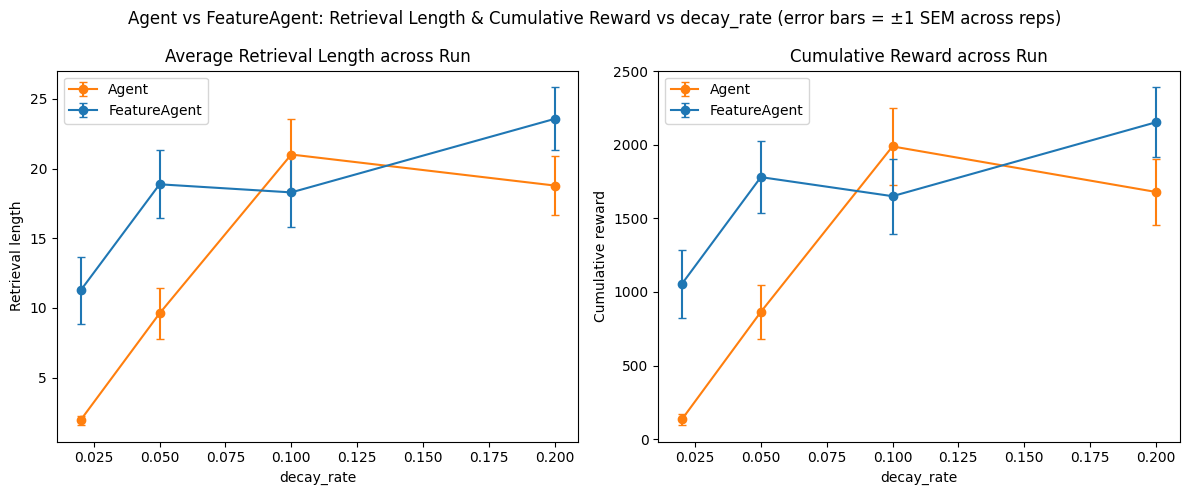

In [10]:
decay_rate_values = [0.02, 0.05, 0.1, 0.2]

agent_avg_len_mean, agent_avg_len_sem, agent_cum_reward_mean, agent_cum_reward_sem = sweep_param(
    lambda env, dr: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=dr),
    decay_rate_values)
feature_avg_len_mean, feature_avg_len_sem, feature_cum_reward_mean, feature_cum_reward_sem = sweep_param(
    lambda env, dr: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=dr),
    decay_rate_values)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].errorbar(decay_rate_values, agent_avg_len_mean, yerr=agent_avg_len_sem, marker="o", capsize=3, label="Agent", color="C1")
axs[0].errorbar(decay_rate_values, feature_avg_len_mean, yerr=feature_avg_len_sem, marker="o", capsize=3, label="FeatureAgent", color="C0")
axs[0].set_xlabel("decay_rate")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length across Run")
axs[0].legend()

axs[1].errorbar(decay_rate_values, agent_cum_reward_mean, yerr=agent_cum_reward_sem, marker="o", capsize=3, label="Agent", color="C1")
axs[1].errorbar(decay_rate_values, feature_cum_reward_mean, yerr=feature_cum_reward_sem, marker="o", capsize=3, label="FeatureAgent", color="C0")
axs[1].set_xlabel("decay_rate")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Cumulative Reward across Run")
axs[1].legend()

fig.suptitle("Agent vs FeatureAgent: Retrieval Length & Cumulative Reward vs decay_rate (error bars = ±1 SEM across reps)")
plt.tight_layout()
plt.savefig("plots/decay_rate_1.png")
plt.show()

rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 5 finished


rep 6 finished


rep 7 finished


rep 8 finished


rep 9 finished


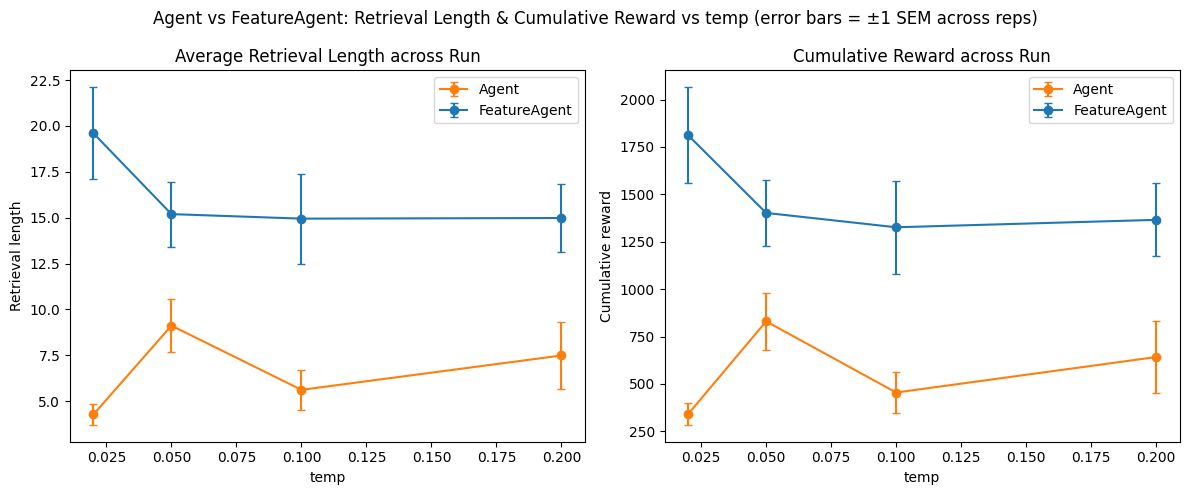

In [11]:
# Mirrors the decay_rate sweep above, but varies temp instead (holding decay_rate
# fixed at the notebook's standard 0.05) - same value set, same exclusion of 0.
temp_values = [0.02, 0.05, 0.1, 0.2]

agent_avg_len_mean_temp, agent_avg_len_sem_temp, agent_cum_reward_mean_temp, agent_cum_reward_sem_temp = sweep_param(
    lambda env, t: model.Agent(gamma=0.9, temp=t, v_i=0, decay_rate=0.05),
    temp_values)
feature_avg_len_mean_temp, feature_avg_len_sem_temp, feature_cum_reward_mean_temp, feature_cum_reward_sem_temp = sweep_param(
    lambda env, t: model.FeatureAgent(env, gamma=0.9, temp=t, decay_rate=0.05),
    temp_values)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].errorbar(temp_values, agent_avg_len_mean_temp, yerr=agent_avg_len_sem_temp, marker="o", capsize=3, label="Agent", color="C1")
axs[0].errorbar(temp_values, feature_avg_len_mean_temp, yerr=feature_avg_len_sem_temp, marker="o", capsize=3, label="FeatureAgent", color="C0")
axs[0].set_xlabel("temp")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length across Run")
axs[0].legend()

axs[1].errorbar(temp_values, agent_cum_reward_mean_temp, yerr=agent_cum_reward_sem_temp, marker="o", capsize=3, label="Agent", color="C1")
axs[1].errorbar(temp_values, feature_cum_reward_mean_temp, yerr=feature_cum_reward_sem_temp, marker="o", capsize=3, label="FeatureAgent", color="C0")
axs[1].set_xlabel("temp")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Cumulative Reward across Run")
axs[1].legend()

fig.suptitle("Agent vs FeatureAgent: Retrieval Length & Cumulative Reward vs temp (error bars = ±1 SEM across reps)")
plt.tight_layout()
plt.savefig("plots/temp.png")
plt.show()

## 4. Decay Rate Sweep - Growing Trauma Network

Repeats the section 3 `decay_rate` sweep (same `decay_rate_values`, same 0 exclusion), but under the growing-trauma network condition from section 2 (a new -50 memory every `TRAUMA_FREQ` retrievals) instead of the original static-trauma network, to see whether the decay-rate effect on retrieval length holds up when the network keeps accruing new aversive content over time.

rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 5 finished


rep 6 finished


rep 7 finished


rep 8 finished


rep 9 finished


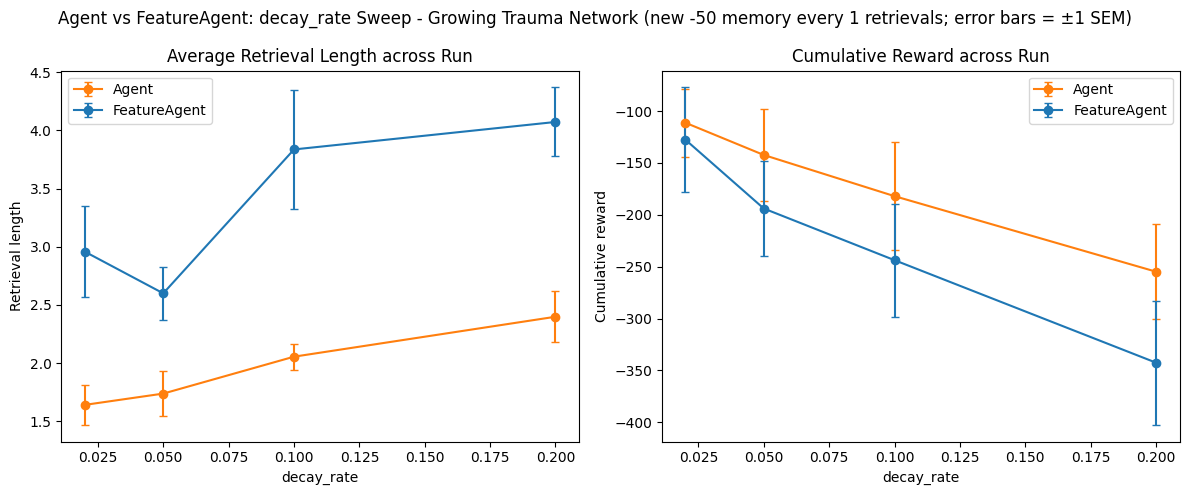

In [12]:
agent_avg_len_mean_gt, agent_avg_len_sem_gt, agent_cum_reward_mean_gt, agent_cum_reward_sem_gt = sweep_param(
    lambda env, dr: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=dr),
    decay_rate_values, trauma=-50, trauma_freq=TRAUMA_FREQ)
feature_avg_len_mean_gt, feature_avg_len_sem_gt, feature_cum_reward_mean_gt, feature_cum_reward_sem_gt = sweep_param(
    lambda env, dr: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=dr),
    decay_rate_values, trauma=-50, trauma_freq=TRAUMA_FREQ)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].errorbar(decay_rate_values, agent_avg_len_mean_gt, yerr=agent_avg_len_sem_gt, marker="o", capsize=3, label="Agent", color="C1")
axs[0].errorbar(decay_rate_values, feature_avg_len_mean_gt, yerr=feature_avg_len_sem_gt, marker="o", capsize=3, label="FeatureAgent", color="C0")
axs[0].set_xlabel("decay_rate")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length across Run")
axs[0].legend()

axs[1].errorbar(decay_rate_values, agent_cum_reward_mean_gt, yerr=agent_cum_reward_sem_gt, marker="o", capsize=3, label="Agent", color="C1")
axs[1].errorbar(decay_rate_values, feature_cum_reward_mean_gt, yerr=feature_cum_reward_sem_gt, marker="o", capsize=3, label="FeatureAgent", color="C0")
axs[1].set_xlabel("decay_rate")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Cumulative Reward across Run")
axs[1].legend()

fig.suptitle(f"Agent vs FeatureAgent: decay_rate Sweep - Growing Trauma Network "
             f"(new -50 memory every {TRAUMA_FREQ} retrievals; error bars = ±1 SEM)")
plt.tight_layout()
plt.savefig("plots/decay_rate_2.png")
plt.show()